### Importing Packages

In [1]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import Subset

import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm 

import scipy
from scipy.optimize import linear_sum_assignment

import copy

import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

from functools import partial

from sklearn.cluster import KMeans

import string

### Seed

In [2]:
SEED = 44

np.random.seed(SEED)
torch.manual_seed(SEED)

### Importing Data

In [3]:
# Transform images to tensors
transform = transforms.ToTensor()

# Load training dataset
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Load test dataset
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

### Helper Functions

In [4]:
def filter_data(dataset, allowed_digits):

    """
    The function filter_data generates a subset of the given MNIST dataset consisting of all and only all of
    the images of digits in allowed_digits

    Args:
        dataset: MNIST dataset 
        allowed_digits: list of digits to look for in dataset

    Returns:
        filtered_dataset: MNIST subset of dataset consisting of all and only all digits in allowed_digits
    """

    labels = dataset.targets

    mask = torch.zeros_like(labels, dtype=torch.bool)

    for digit in allowed_digits:

        mask |= (labels == digit)

    indices = torch.where(mask)[0]

    filtered_dataset = Subset(dataset, indices)

    return filtered_dataset

In [5]:
def train_model(model, training_data_loader, testing_data_loader, 
                training_digit_group, num_epochs, 
                penalty_function=None, λ=1,
               ):

    base_loss_function = nn.CrossEntropyLoss(reduction='mean')

    if penalty_function is None:
        penalty_function = null_penalty
        
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    cm_epoch_set = []
    pca_epoch_set = []
    scaler_epoch_set = []
    kmeans_epoch_set = []

    for epoch in tqdm(range(num_epochs)):

        ############################
        #### TRAINING
        ############################

        model.train()

        total_loss = 0.0
        
        for inputs, labels in training_data_loader:

            optimizer.zero_grad()

            outputs = model(inputs)

            loss = base_loss_function(outputs, labels) + λ*penalty_function(model, inputs)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Total Training Loss: {total_loss:.4f}")

        ############################
        #### VALIDATING
        ############################
            
        cm = get_cm(model, testing_data_loader)
        pca, scaler = get_pca(model, testing_data_loader, training_digit_group)
        kmeans = get_kmeans(model, testing_data_loader, seed=42)

        cm_epoch_set.append(cm)
        pca_epoch_set.append(pca)
        scaler_epoch_set.append(scaler)
        kmeans_epoch_set.append(kmeans)

    return copy.deepcopy(model), cm_epoch_set, pca_epoch_set, scaler_epoch_set, kmeans_epoch_set

### get_cm(model, testing_data_loader)

Builds a confusion matrix for the given model using the testing data from testing_data_loader. Predictions are made by taken as the highest probability logit in the output of the mode:

$$prediction = \underset{i\in[0, 9]}{max}\hspace{0.1cm}l_{i}$$

$$\mathbf{N} = \underset{predicted \hspace{0.1cm}labels \hspace{0.1cm}\times\hspace{0.1cm} true \hspace{0.1cm}labels}{\begin{bmatrix} n_{1,1} & n_{1,2} & \cdots & n_{1, 10} \\
n_{2,1} & n_{2,2} & \cdots & n_{2, 10} \\ 
\vdots & \vdots & \ddots & \vdots \\
n_{10,1} & n_{10,2} & \cdots & n_{10, 10}\end{bmatrix}}$$

    Args:
        model                : neural network type; trained neural network
        testing_data_loader  : list type; list of DataLoaders of properly sorted MNIST testing images

    Returns:
        cm                   : array type; confusion matrix visualizing how the model predicts (rows) images of a specific true label (columns)

In [6]:
def get_cm(model, testing_data_loader):

    model.eval()

    with torch.no_grad():

        cm = np.zeros((10, 10))

        for true_label in range(10):

            for inputs, labels in testing_data_loader[true_label]:

                outputs = model(inputs)

                predicted_labels = torch.argmax(outputs, dim=1).numpy()

                np.add.at(cm, (predicted_labels, true_label), 1)

        return cm

### get_pca(model, testing_data_loader, digit_group)

Performs a principal component analysis (PCA) on the hidden-state representation of a group of digits digit_group within the neural network model. PCA is done by computing eigenvalue-eigenvector pairs of the Pearson-correlation matrix (covariance matrix is computed as feature covariances of feature-standardized data):

$$ \{\lambda_i, \hat{u}_i\}: \hspace{1cm} \mathbf{C}\hat{u}=\lambda_i\hat{u}_i$$

$$\underset{num \hspace{0.1cm}features\hspace{0.1cm}\times num \hspace{0.1cm}features}{\mathbf{C}}=\frac{1}{num\hspace{0.1cm}samples-1}\underset{num\hspace{0.1cm}features\hspace{0.1cm}\times batch\hspace{0.1cm}size}{\mathbf{Z}^T}\hspace{0.3cm}\underset{batch \hspace{0.1cm}size\hspace{0.1cm}\times num \hspace{0.1cm}features}{\mathbf{Z}}$$

    Args:
        model: neural network type; the neural network whose hidden representation we are probing
        testing_data_loader: DataLoader type; the properly sorted testing data used to evaluate model
        digit_group: list type; list of digits we are probing for the hidden representation of

    Returns:
        pca: pca type; pca fit to the standardized hidden representation data
        scaler: ? type; scaler used to fit the pca 

In [7]:
def get_pca(model, testing_data_loader, digit_group):

    model.eval()

    with torch.no_grad():
    
        all_batches = []                                             # shape: null
 
        for digit in digit_group:
        
            for inputs, labels in testing_data_loader[digit]:
            
                hidden_outputs = model.hidden(inputs).numpy()        # shape: (batch_size, hidden_size)
       
                all_batches.append(hidden_outputs)                   
 
        data = np.concatenate(all_batches, axis=0)                   # shape: (num_batchs X batch_size, hidden_size)
 
        scaler = StandardScaler()
        standardized_data = scaler.fit_transform(data)
 
        pca = PCA()
        pca.fit(standardized_data)                                   # shape: (hidden_size, hidden_size) (since hidden_size < num_batchs X batch_size)
 
        return pca, scaler

### get_kmeans(model, testing_data_loader, seed)

Returns a k-means classification confusion matrix of model's hidden representation of all digits using images from testing_data_loader. 

$$\mathbf{N} = \underset{predicted \hspace{0.1cm}class \hspace{0.1cm}\times\hspace{0.1cm} true \hspace{0.1cm}labels}{\begin{bmatrix} n_{1,1} & n_{A,2} & \cdots & n_{A, 10} \\
n_{B,1} & n_{B,2} & \cdots & n_{B, 10} \\ 
\vdots & \vdots & \ddots & \vdots \\
n_{J,1} & n_{J,2} & \cdots & n_{J, 10}\end{bmatrix}}$$

    Args: 
        model: neural network type; the model the hidden representation k-means are done on
        testing_data_loader: list type; list of DataLoader types of MNIST testing images sorted by digit
        seed                  : int type; seed number for repeatable stochastic results

    Returns:
        cm: array type; confusion matrix of predicted classifications vs. their true label

In [8]:
def get_kmeans(model, testing_data_loader, seed):

    model.eval()

    with torch.no_grad():

        all_hidden_outputs = []
        all_labels = []

        for digit in range(10):

            for inputs, labels in testing_data_loader[digit]:

                hidden_outputs = model.hidden(inputs)

                all_hidden_outputs.append(hidden_outputs.numpy())
                all_labels.append(labels.squeeze().numpy())

        data = np.concatenate(all_hidden_outputs, axis=0)
        true_labels = np.concatenate(all_labels, axis=0)

        kmeans = KMeans(n_clusters=10, random_state=seed)
        kmeans.fit(data)
        predicted_labels = kmeans.labels_

        cm = np.zeros((10, 10))

        np.add.at(cm, (predicted_labels, true_labels), 1)

    return cm

In [108]:
def get_maxims(model, clusts, num_steps=500, ε=0.01):

    model.eval()

    num_clusts = clusts.shape[0]
    clusts_size = clusts.sum(dim=1, keepdim=True)           # shape: (num_clusters, 1) 
    clusts_norm = clusts / clusts_size                      # shape: (num_clusters, num_neurons)

    maxims = torch.randn((num_clusts, 1, 28, 28), requires_grad = True)

    optimizer = optim.Adam([maxims], lr=ε)

    for step in range(num_steps):
        
        optimizer.zero_grad()
 
        conv_out = model.flatten(model.convout(maxims))                 # shape: (num_clusts, 64 X 7 X 7, )
        a1 = model.relu(model.layer1(conv_out))                           # shape: (num_clusts, num_neurons1)
        a2 = model.relu(model.layer2(a1))                          # shape: (num_clusts, num_neurons2)
        a3 = model.layer3(a2)                                   # shape: (num_clusts,  num_neurons3)
        A = torch.cat((a1, a2, a3), dim=1)                          # shape: (num_clusts, num_neurons_tot)

        clusts_activations = torch.diagonal(A @ clusts_norm.T)                     # shape: (num_clusts, num_clusters)
        
        benefit = clusts_activations
        loss = -benefit.mean()
        loss.backward()
        optimizer.step()

    return maxims.detach()                               # shape: (num_clusts, 1, 28, 28)

### pca_drift_penalty(model, inputs, old_pca_components)

This function penalizes how much of the current hidden representation of the inputs lies within the span of some subset of the old principal components. The penalty is computed according to the following rule:


$$\underset{(batch \hspace{0.1cm}size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{h}_i} = \underset{(batch \hspace{0.1cm}size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{H}_i}\hspace{0.3cm}\underset{(hidden\hspace{0.1cm} size \hspace{0.1cm}\times\hspace{0.1cm} pca\hspace{0.1cm} size)}{\mathbf{P^T}}\hspace{0.3cm}\underset{(pca\hspace{0.1cm} size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{P}}$$

$$\underset{(batch\hspace{0.1cm} size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{R}_i} = \underset{(batch\hspace{0.1cm} size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{H}_i}-\underset{(batch\hspace{0.1cm} size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{h}_i}$$

$$\underset{1\times 1}{penalty} = \frac{1}{batch\hspace{0.1cm}size\hspace{0.1cm}\times\hspace{0.1cm}
hidden\hspace{0.1cm}size}\sum_{n=1}^{batch\hspace{0.1cm} size}\sum_{m=1}^{hidden\hspace{0.1cm} size}R_{nm}^2$$

    Args:
        model                      : Neural Network type; neural network being trained
        inputs                     : tensor type; input data the neural network is being trained on
        old_pca_components         : array type; subspace the hidden representation will be projected onto and reconstructed out of

    Returns:
        penalty                    : float type; penalty (with auto-grad) to be added to loss function in neural network training
        

In [9]:
def pca_drift_penalty(model, inputs, old_pca_components):

    if old_pca_components is None:
        return torch.tensor(0.0)
    
    V = torch.tensor(
        old_pca_components,                            # shape: (pca_size, hidden_size)
        dtype=torch.float32
    )

    hidden_outputs = model.hidden(inputs)              # shape: (batch_size, hidden_size)

    projections   = hidden_outputs @ V.T               # shape: (batch_size, hidden_size) X (hidden_size, pca_size) = (batch_size, pca_size)
    reconstructions = projections @ V                  # shape: (batch_size, pca_size) X (pca_size, hidden_size) = (batch_size, hidden_size)

    residual = hidden_outputs - reconstructions        # shape: (batch, hidden_size)
    penalty  = torch.mean(residual ** 2)               # shape: ()

    return penalty

### corrs_penalty(model, inputs, cluster_labels, cluster_corrs, old_model)

This function penalizes how much the weights of neurons drift from their original values, weighted by the correlation of the neurons' parent cluster.


$$penalty = \sum_{clusters}\rho_{C, old}\sum_{neurons}(||(\vec{W}_{n, new}\otimes b_{n, new})-(\vec{W}_{n, old}\otimes b_{n, old})||^2$$


    Args:
        model                      : Neural Network type; neural network being trained
        inputs                     : tensor type; input data the neural network is being trained on (VACUOUS PASS)
        cluster_labels             : array type; arary mapping neurons to a parent cluster
        cluster_corrs              : array type; array type assigning a correlative importance to each parent cluster
        old_model                  : Neural Network type; old neural network used to constrain further training

    Returns:
        penalty                    : float type; penalty (with auto-grad) to be added to loss function in neural network training

In [10]:
def corrs_penalty(model, inputs, cluster_labels, cluster_corrs, old_model):

    weights = torch.tensor(cluster_corrs[cluster_labels-1], dtype=torch.float32)                             # shape: (total_num_neurons, )

    penalty = torch.tensor(0.0)                                                                              # shape: ()

    layer_pairs = [(model.layer1, old_model.layer1),
                  (model.layer2, old_model.layer2),
                  (model.layer3, old_model.layer3)
                  ]

    neuron_offset = 0

    for layer, old_layer in layer_pairs:

        num_neurons = layer.weight.shape[0]

        params = torch.cat((layer.weight, layer.bias.unsqueeze(1)), dim=1)                                  # shape: (num_neurons, num_weights+1)
        old_params = torch.cat((old_layer.weight.detach(), old_layer.bias.detach().unsqueeze(1)), dim=1)    # shape: (num_neurons, num_weights+1)

        drift = (params-old_params).pow(2).sum(dim=1)                                                       # shape: (num_neurons,)

        penalty = penalty + (weights[neuron_offset:neuron_offset+num_neurons]*drift).sum()                  # shape: ()

        neuron_offset = neuron_offset + num_neurons

    return penalty

In [11]:
def logit_penalty(model, inputs, old_model, old_representatives):
    
    old_model.eval()

    weights = model.layer3.weight                                # shape: (10, 64)
    old_weights = old_model.layer3.weight.detach()               # shape: (10, 64)

    drift = (weights-old_weights) @ old_representatives.T           # shape: (10, 64) X (64, 3)

    penalty = (drift).pow(2).sum()

    return penalty

In [12]:
def get_representatives(model, testing_data_loader, digit_group):

    model.eval()

    with torch.no_grad():

        all_representatives = []

        for digit in digit_group:

            all_batches = []

            for inputs, labels in testing_data_loader[digit]:

                hidden_outputs = model.hidden(inputs).numpy()                                   # shape: (batch_size, 64)

                all_batches.append(hidden_outputs)

            all_batches = np.concatenate(all_batches, axis=0)                            # shape: (num_batches X batch_size, 64)

            representative = all_batches.mean(axis=0, keepdims=True)                                    # shape: (64, )

            all_representatives.append(representative)

        all_representatives = np.concatenate(all_representatives, axis=0)            # shape: (3, 64)

        return all_representatives                                                      # shape: (3, 64)
         

### null_penalty(model inputs)

Null penalty, always returns tensor(0.0).

    Args:
        model                      : Neural Network type; neural network being trained (VACUOUS PASS)
        inputs                     : tensor type; input data the neural network is being trained on (VACUOUS PASS)

    Returns:
        penalty                    : float type; penalty (with auto-grad) to be added to loss function in neural network training (always tensor(0.0))

In [13]:
def null_penalty(model, inputs):
    return torch.tensor(0.0)

### monte_carlo_cgm(dim_subspace, dim_space, n_samples=100_000, seed=42)

Monte Carlo estimate (N = n_samples, from seed) of the mean and standard deviation of the cross-Gram-matrices two randomly sampled dim_subspace-dimensional orthonormal bases $\mathcal{U}, \mathcal{V}\in\mathbb{R}^{dim\hspace{0.1cm}space \hspace{0.1cm}\times\hspace{0.1cm} dim \hspace{0.1cm} subspace}$. The n_samples pairs of subspaces are drawn as a dim_space by dim_subspace array of dim_subspace samples from the dim_space dimensional standard normal distribution, $\mathcal{N}_{dim\hspace{0.1cm}space}(0, 1)$ and orthonormalized. 

Analytical Expressions (dim_subspace=1):

$$\mu_{|\hat{u}\cdot\hat{v}|} = \frac{\Gamma\left(\frac{d}{2}\right)}{\sqrt{\pi}\Gamma\left(\frac{d+1}{2}\right)}\overset{d=64}{\approx}0.100$$

$$\sigma_{|\hat{u}\cdot\hat{v}|} = \sqrt{\frac{1}{d}-\mu_{|\hat{u}\cdot\hat{v}|}^2}\overset{d=64}{\approx}0.075$$

    Args:
        dim_subspace          : int type; dimensionality of subspaces being drawn
        dim_space             : int type; dimensionality of the overall space embedding the subspaces
        n_samples             : int type; number of sample drawn for the Monte Carlo approximation
        seed                  : int type; seed number for repeatable stochastic results

    Returns:
        μ                     : float type; sample mean computed by Monte Carlo
        σ                     : float type; sample standard deviation computed by Monte Carlo

In [14]:
def monte_carlo_cgm(dim_subspace, dim_space, n_samples=100_000, seed=42):

    rng = np.random.default_rng(seed)
 
    U = rng.standard_normal((n_samples, dim_space, dim_subspace))          # shape: (n_samples, dim_space, dim_subspace)
    V = rng.standard_normal((n_samples, dim_space, dim_subspace))          # shape: (n_samples, dim_space, dim_subspace)

    U, _ = np.linalg.qr(U)                                                   # shape: (n_samples, dim_space, dim_subspace)
    V, _ = np.linalg.qr(V)                                                   # shape: (n_samples, dim_space, dim_subspace)

    cgm = np.abs(np.einsum("ndi, ndj -> nij", U, V))                             # shape: (n_samples, dim_subspace, dim_subspace)

 
    μ = np.mean(cgm)                      # shape: ()
    σ = np.std(cgm)                       # shape: ()  
 
    return μ, σ

In [15]:
def get_hungarian(benefit_matrix):

    tol = 1e-10

    # Normalize benefit matrix to [0,1]
    benefit_matrix = np.clip(benefit_matrix, 0, 1)

    # Convert trace maximization into trace minimization
    cost_matrix = 1 - benefit_matrix

    n, m = cost_matrix.shape

    cost_matrix -= cost_matrix.min(axis=0, keepdims=True)
    cost_matrix -= cost_matrix.min(axis=1, keepdims=True)

    # Starring 0s
    stars_matrix = np.zeros_like(cost_matrix, dtype=bool)

    row_has_star = np.zeros(n, dtype=bool)
    col_has_star = np.zeros(m, dtype=bool)

    # Choosing sequentially unclaimed rows or columns with 0s
    for i in range(n):

        for j in range(m):

            if cost_matrix[i,j] <= tol and not row_has_star[i] and not col_has_star[j]:

                stars_matrix[i,j] = 1
                row_has_star[i] = 1
                col_has_star[j] = 1

    # Main loop

    # Outer Loop
    while True:

        row_covered = np.zeros(n, dtype=bool)
        col_covered = np.zeros(m, dtype=bool)
        primes_matrix = np.zeros_like(cost_matrix, dtype=bool)

        for j in range(m):

            for i in range(n):

                col_covered[j] |= stars_matrix[i][j] 

        if col_covered == np.ones(m, dtype=bool):

            break 

        # Inner Loop
        while True:

            for r in range(n):

                for c in range(m):

                    if cost_matrix[r,c] < tol and not row_covered[r] and not col_covered[c]:

                        primes_matrix[r, c] = 1

                        # Outcome B
                        for c_star in range(m):

                            if stars_matrix[r, c_star]:

                                row_covered[r] = 1
                                col_covered[c_star] = 0
                                break
                                
                            




                    
            

### get_all_activations(model, testing_data_loader, digit_group)

This function gets the activations of all hidden layers of the given model when seeing images of the given digit group from the given testing data loader. 

    Args:
        model: neural network type; the model we are gather all layer activations from
        testing_data_loader: list type; list of DataLoader types of MNIST testing images sorted by digit
        digit_group: list type; list of digits input into the network generating activations

    Returns:
        all_activations: array type; array of all activations of shape (num_batches X batch_size, num_neurons_tot) 
        all_labels: array type; array of all labels of inputs into the model



In [16]:
def get_all_activations(model, testing_data_loader, digit_group):

    all_a1, all_a2, all_a3, all_labels = [], [], [], []

    model.eval()

    with torch.no_grad():
    
        for digit in digit_group:

            for inputs, labels in testing_data_loader[digit]:

                a1 = model.forward1(inputs).numpy()             # shape: (batch_size, num_neurons_1)
                a2 = model.forward2(inputs).numpy()             # shape: (batch_size, num_neurons_2) 
                a3 = model.forward3(inputs).numpy()             # shape: (batch_size, num_neurons_3)

                all_a1.append(a1)                               # shape: (num_batches, batch_size, num_neurons_1)
                all_a2.append(a2)                               # shape: (num_batches, batch_size, num_neurons_2)
                all_a3.append(a3)                               # shape: (num_batches, batch_size, num_neurons_3)
                all_labels.append(labels.numpy())               # shape: (num_batches, batch_size)


        all_a1 = np.concatenate(all_a1, axis=0)                 # shape: (num_batches X batch_size, num_neurons_1)
        all_a2 = np.concatenate(all_a2, axis=0)                 # shape: (num_batches X batch_size, num_neurons_2)
        all_a3 = np.concatenate(all_a3, axis=0)                 # shape: (num_batches X batch_size, num_neurons_3)
        all_labels = np.concatenate(all_labels, axis=0)         # shape: (num_batches X batch_size)

        all_activations = np.concatenate((all_a1, all_a2, all_a3), axis=1) # shape: (num_batches X batch_size, num_neurons_tot)

    return all_activations, all_labels

### get_correlation(activations)

Returns the Pearson correlation matrix of the array of all activations.

$$\underset{num\hspace{0.1cm}samples\times \hspace{0.1cm} num\hspace{0.1cm}features}{\mathbf{Z}_{ij}}=\frac{\underset{nsamples\times nvariables}{\mathbf{X}_{ij}}-\underset{nsamples\times nvariables}{\bar{\mathbf{X}}_{:,j}}}{\sigma_j}$$

$$\underset{num \hspace{0.1cm}features\hspace{0.1cm}\times num \hspace{0.1cm}features}{\mathbf{P}}=\frac{1}{num\hspace{0.1cm}samples-1}\underset{num\hspace{0.1cm}features\hspace{0.1cm}\times num\hspace{0.1cm}samples}{\mathbf{Z}^T}\hspace{0.3cm}\underset{num\hspace{0.1cm}samples\hspace{0.1cm}\times num \hspace{0.1cm}features}{\mathbf{Z}}$$

$$\forall i,j \hspace{0.5cm} P_{ij}\in[-1, 1]$$

    Args:
        activations: array type; array of all samples of neuron activations of all layers

    Returns:
        corr_matrix: array type; Pearson correlation matrix
    

In [17]:
def get_correlation(activations):

    corr_matrix = np.corrcoef(activations.T)                # shape: (num_neurons_tot, num_neurons_tot)

    np.nan_to_num(corr_matrix, nan=0.0, copy=False)         # shape: (num_neurons_tot, num_neurons_tot)

    return corr_matrix                                      # shape: (num_neurons_tot, num_neurons_tot)

### get_cluster(corr_matrix, corr_threshold)

Performs agglomerative clustering on neurons using $1-|P_{ij}|$ as the distance between neurons $i$ and $j$. 

    Args:
        corr_matrix: array type; Pearson correlation matrix of neuron activations
        corr_threshold: float type; the minimum necessary absolute Pearson correlation for two neurons to be clustered

    Returns:
        cluster_labels: array type; cluster IDs of all neurons in neural network

In [18]:
def get_cluster(corr_matrix, corr_threshold=0.9):

    corr_matrix = np.nan_to_num(corr_matrix, nan=0.0, copy=False)          # shape: (num_neurons_tot, num_neurons_tot)

    dist = 1 - np.clip(np.abs(corr_matrix), 0, 1)                          # shape: (num_neurons_tot, num_neurons_tot)
    np.fill_diagonal(dist, 0)                                              # shape: (num_neurons_tot, num_neurons_tot)

    condensed = squareform(dist, checks=False)                             # shape: (num_neurons_tot X (num_neurons_tot-1)/2, )

    Z = linkage(condensed, method="average")                               
    cluster_labels = fcluster(Z, t=1-corr_threshold, criterion="distance")        # shape: (num_neurons_tot, )

    return cluster_labels                                                  # shape: (num_neurons_tot, )

### get_cluster_digit_correlation(cluster_labels, digit_group, all_activations, all_labels)

Computes a Pearson correlation between each neuron cluster and the 10 digits, returns the maximum for each cluster. 

    Args:
        cluster_labels: array type; cluster IDs of all neurons in neural network
        digit_group: list type; list of digits input into the network generating activations
        all_activations: array type; array of all activations of shape (num_batches X batch_size, num_neurons_tot)
        all_labels: array type; array of all labels of inputs into the model

    Returns:
        corrs_cluster_set: array type; array of maximum Pearson correlation of each neuron cluster
        
        

In [19]:
def get_cluster_digit_correlation(cluster_labels, digit_group, all_activations, all_labels):

    corrs_cluster_set = []                                                                # shape: (num_clusters)

    num_clusters = np.max(cluster_labels)

    for cluster_id in range(1, num_clusters+1):

        corrs_digit_set = []                                                               # shape: (num_digits, )

        cluster_mask_bool = cluster_labels == cluster_id                                   # shape: (num_neurons_tot, ) bool

        coarse_cluster_activations = all_activations[:, cluster_mask_bool].mean(axis=1)    # shape: (num_samples, )

        for digit in digit_group:

            binary_label_mask = np.where(all_labels==digit, 1, 0)                          # shape: (num_samples, ) binary

            corr = np.corrcoef(coarse_cluster_activations, binary_label_mask)[0, 1]        # shape: ()

            corr = np.nan_to_num(corr, nan=0.0)

            corrs_digit_set.append(corr)

        corrs_cluster_set.append( np.max( np.abs(corrs_digit_set) ) )

    return np.array(corrs_cluster_set)                                                     # shape: (num_clusters)

In [20]:
def make_colormap(vmin, vmax, neutral_low, neutral_high, mid1, mid2):
    
    def p(z):
        return (z - vmin) / (vmax - vmin)

    cmap = LinearSegmentedColormap.from_list(
        'cgm_zones',
        [
            (p(vmin),         '#2166AC'),
            (p(neutral_low),  '#D1E5F0'),
            (p(neutral_low),  '#B0B0B0'),
            (p(neutral_high), '#B0B0B0'),
            (p(neutral_high), '#FFFFCC'),
            (p(mid1),         '#FD8D3C'),
            (p(mid2),         '#D7191C'),
            (p(vmax),         '#67000D'),
        ],
        N=512
    )
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    return cmap, norm

In [21]:
def plot_cms(cm_set, normalize=True):

    num_groups, num_epochs = len(cm_set), len(cm_set[0])

    fig, axes = plt.subplots(
                            nrows=num_epochs,
                            ncols=num_groups,
                            figsize=(4 * num_groups, 5 * num_epochs)
                            )
    
    axes = np.array(axes).reshape(num_epochs, num_groups)

    for m in range(num_groups):          
        for n in range(num_epochs):     

            ax = axes[n, m]
            cm = cm_set[m][n]

            if normalize:
                cm = cm / cm.sum(axis=0, keepdims=True)
                im = ax.imshow(cm, cmap='Blues')
                for i in range(cm.shape[0]):
                    for j in range(cm.shape[1]):
                        ax.text(
                            j, i,
                            f"{cm[i, j]:.0%}",
                            ha='center',
                            va='center',
                            color='black',
                            fontsize=8
                            )

            else: 
                im = ax.imshow(cm, cmap='Blues')
                for i in range(cm.shape[0]):
                    for j in range(cm.shape[1]):
                        ax.text(
                            j, i,
                            str(int(cm[i, j])),
                            ha='center',
                            va='center',
                            color='black',
                            fontsize=8
                            )

            ax.set_title(f"Training Group {m+1}, Epoch {n+1}")

            ax.set_xlabel("True Label")
            ax.set_ylabel("Predicted Label")

            ax.set_xticks(range(10))
            ax.set_yticks(range(10))

    # One shared colorbar (important)
    fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)

    plt.show()

    return

In [22]:
def plot_cgms(pca_set, μ_cgm, σ_cgm, window=(-1, -1), diagonalize=False):

    ###########################################
    #### MAKING CGMS
    ###########################################
    
    num_groups, num_epochs = len(pca_set), len(pca_set[0])
    flattened_pca_set = np.reshape(list(pca_set.values()), (-1))
    num_plots = len(flattened_pca_set)

    
    lower, upper = window
    
    if lower == -1:
        lower = 0
        
    if upper == -1:
        upper = flattened_pca_set[0].components_.shape[0]
            

    plot_set = []

    for i in range(num_plots):

        pca_components_A = flattened_pca_set[num_epochs-1].components_
        pca_components_B = flattened_pca_set[i].components_

        cgm_i = np.abs(pca_components_A @ pca_components_B.T)
        z_cgm_i = (cgm_i-μ_cgm)/σ_cgm
        wz_cgm_i = z_cgm_i[lower:upper, lower:upper]

        if diagonalize:

            cost = 1 - wz_cgm_i
            rows, cols = linear_sum_assignment(cost)
            dwz_cgm_i = wz_cgm_i[:, cols]
            plot_set.append(dwz_cgm_i)

        else:

            plot_set.append(wz_cgm_i)

    
    ###########################################
    #### MAKING PLOTS
    ###########################################

    cgm_cmap, cgm_norm = make_colormap(
                                            vmin=-2,
                                            vmax=12,
                                            neutral_low=-2,     
                                            neutral_high=4,
                                            mid1 = 6,
                                            mid2 = 9
                                        )
 
    CGM_TICKS  = [-2, -1.3,         0,              2,        4,                8,       12]
    CGM_LABELS = ['-2', '-1.3\n(min)', '0\n(mean)', '2', '4',  '8', '12']
    
    fig, axes = plt.subplots(
                            nrows=num_epochs,
                            ncols=num_groups,
                            figsize=(4 * num_groups, 5 * num_epochs)
                            )

    axes = np.array(axes).reshape(num_epochs, num_groups)

    for i in range(num_plots):

        g_earlier = i//num_epochs
        g_later = (i+1)//num_epochs
        e_earlier = i%num_epochs
        e_later = (i+1)%num_epochs

        ax = axes[e_earlier, g_earlier]

        plot_i = plot_set[i]

        im = ax.imshow(plot_i, cmap=cgm_cmap, norm=cgm_norm)

        ax.set_title(f"z-CGM of Training Group {g_earlier+1}, Epoch {e_earlier+1} \n on Training Group {0+1}, Epoch {num_epochs}")

        ax.set_xlabel(f"PCs of Training Group {g_earlier+1}, Epoch {e_earlier+1}")
        ax.set_ylabel(f"PCs of Training Group {0+1}, Epoch {num_epochs}")

    cbar = fig.colorbar(im, ax=axes, ticks=CGM_TICKS, fraction=0.02, pad=0.04)
    cbar.ax.set_yticklabels(CGM_LABELS)
    cbar.set_label("PC overlap (σ above random baseline)", rotation=270, labelpad=20)

    plt.show()
    
    return

In [23]:
def plot_kmeans(kmeans_set, diagonalize=False, normalize=True):

    num_groups, num_epochs = len(kmeans_set), len(kmeans_set[0])

    fig, axes = plt.subplots(
                            nrows=num_epochs,
                            ncols=num_groups,
                            figsize=(4 * num_groups, 5 * num_epochs)
                            )
    
    axes = np.array(axes).reshape(num_epochs, num_groups)

    for m in range(num_groups):          
        for n in range(num_epochs):     

            ax = axes[n, m]
            cm = kmeans_set[m][n]

            if diagonalize:
                cost = np.max(cm) - cm
                rows, cols = linear_sum_assignment(cost)
                cm = cm[:, cols]

            if normalize:
                cm = cm / cm.sum(axis=0, keepdims=True)
                im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
                for i in range(cm.shape[0]):
                    for j in range(cm.shape[1]):
                        ax.text(
                            j, i,
                            f"{cm[i, j]:.0%}",
                            ha='center',
                            va='center',
                            color='black',
                            fontsize=8
                            )

            else: 
                im = ax.imshow(cm, cmap='Blues')
                for i in range(cm.shape[0]):
                    for j in range(cm.shape[1]):
                        ax.text(
                            j, i,
                            str(int(cm[i, j])),
                            ha='center',
                            va='center',
                            color='black',
                            fontsize=8
                            )

            ax.set_title(f"Training Group {m+1}, Epoch {n+1}")

            ax.set_xlabel("True Label")
            ax.set_ylabel("Predicted Class")

            ax.set_xticks(range(10))
            ax.set_yticks(range(10))
            ax.set_yticklabels(list(string.ascii_uppercase[:10]))
            

    # One shared colorbar (important)
    fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)

    plt.show()

    return

In [102]:
def plot_maxims(maxims):

    num_plots = len(maxims)

    num_cols = 10

    if num_plots%num_cols == 0:
        num_rows = num_plots//num_cols
    else:
        num_rows = num_plots//num_cols + 1


    fig, axes = plt.subplots(nrows = num_rows, ncols=num_cols, figsize=(6*num_cols, 6*num_rows))

    axes = np.array(axes).reshape(num_rows, num_cols)

    for n in range(num_rows):
        for m in range(num_cols):

            ax = axes[n, m]

            if num_cols*n+m >= num_plots:
                ax.axis("off")
                continue

            image = 1-maxims[num_cols*n+m].squeeze().clamp(0, 1)

            im = ax.imshow(image, cmap="gray")

            ax.set_title(f"Cluster {num_cols*n+m+1} Optimal Image")

    plt.show()

### Training Data

In [26]:
training_digit_groups = [[0, 1, 2], [3, 4, 5], [6, 7, 8, 9]]

In [27]:
training_groups = []

In [28]:
num_training_groups= len(training_digit_groups)

for i in range(num_training_groups):

    training_digit_group = training_digit_groups[i]

    X = filter_data(train_dataset, training_digit_group)

    Y = DataLoader(X, batch_size=64, shuffle=True)

    training_groups.append(Y)

### Testing Data

In [29]:
testing_digit_groups = [[i] for i in range(10)]

In [30]:
testing_groups = []

In [31]:
num_testing_groups = len(testing_digit_groups)

for i in range(num_testing_groups):

    testing_digit_group = testing_digit_groups[i]

    X = filter_data(test_dataset, testing_digit_group)

    Y = DataLoader(X, batch_size=64, shuffle=True)

    testing_groups.append(Y)

### Training/Testing Data Info

In [32]:
for training_inputs, training_labels in training_groups[0]:
    print(training_inputs.shape, training_labels.shape)
    print(training_labels)
    break

for testing_inputs, testing_labels in testing_groups[0]:
    print(testing_inputs.shape, testing_labels.shape)
    print(testing_labels)
    break

torch.Size([64, 1, 28, 28]) torch.Size([64])
tensor([0, 0, 2, 1, 1, 2, 2, 1, 2, 0, 2, 0, 1, 1, 1, 1, 1, 0, 1, 2, 2, 2, 2, 1,
        0, 2, 2, 1, 1, 0, 0, 1, 1, 0, 1, 2, 2, 1, 0, 1, 0, 2, 0, 0, 1, 0, 0, 2,
        0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 2, 2, 2, 2, 0, 2])
torch.Size([64, 1, 28, 28]) torch.Size([64])
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


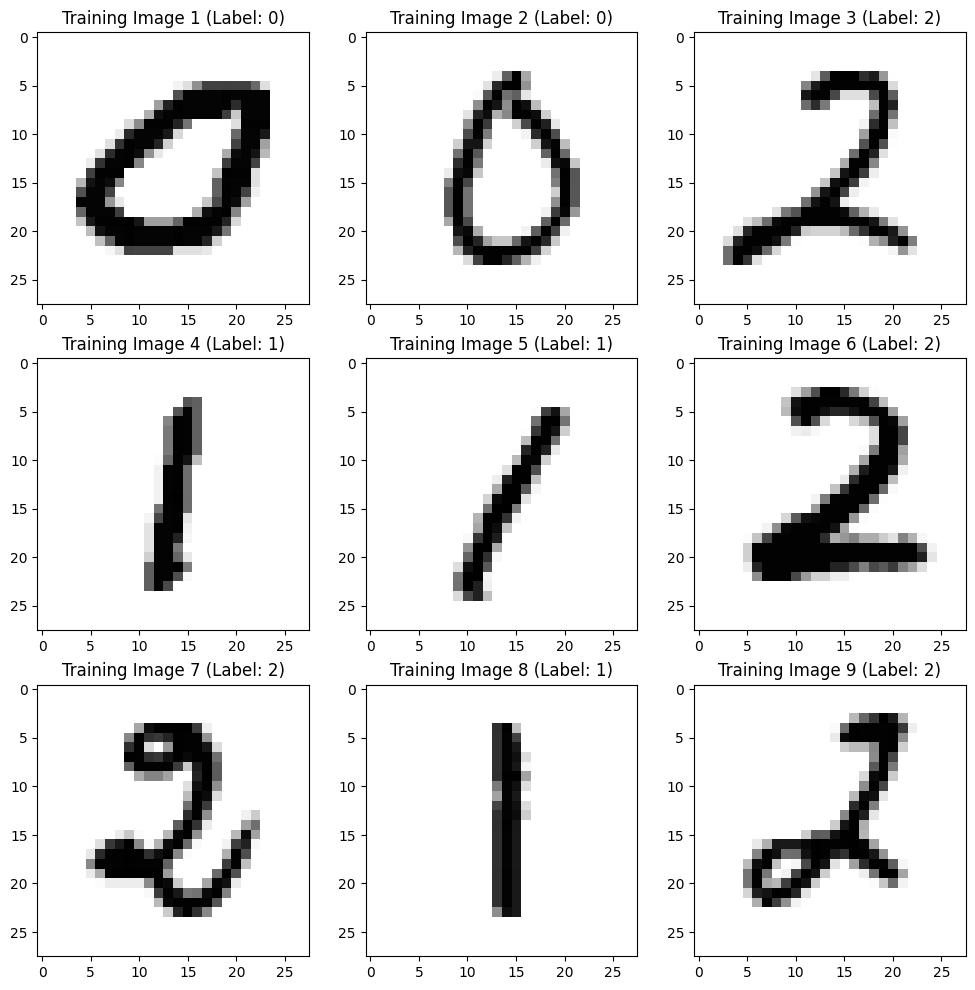

In [33]:
num_rows, num_cols = 3, 3
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(4*num_rows, 4*num_cols))

axes = np.array(axes).reshape(num_rows, num_cols)

for n in range(num_rows):
    for m in range(num_cols):

        ax = axes[n, m]
        image = 1-training_inputs[3*n+m].squeeze().clamp(0,1)

        im = ax.imshow(image, cmap="gray")

        ax.set_title(f"Training Image {3*n+m+1} (Label: {training_labels[3*n+m]})")

plt.show()

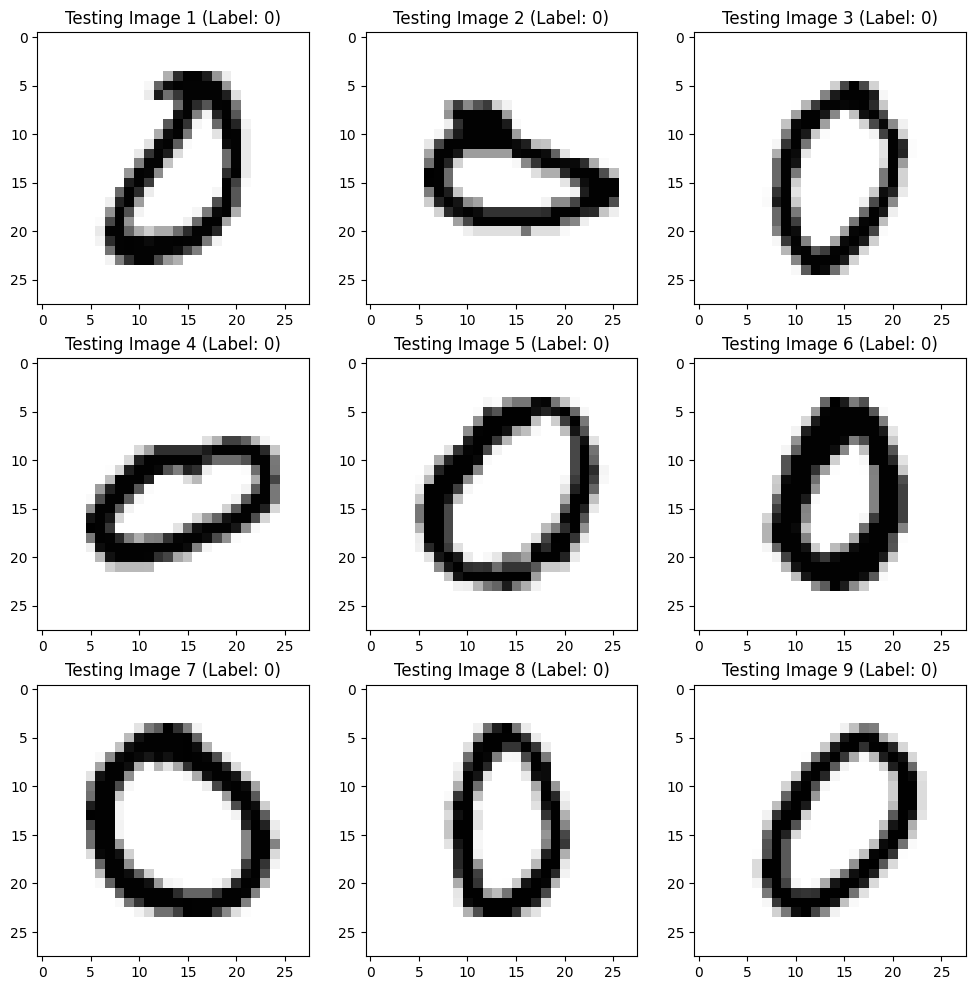

In [34]:
num_rows, num_cols = 3, 3
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(4*num_rows, 4*num_cols))

axes = np.array(axes).reshape(num_rows, num_cols)

for n in range(num_rows):
    for m in range(num_cols):

        ax = axes[n, m]
        image = 1-testing_inputs[3*n+m].squeeze().clamp(0, 1)

        im = ax.imshow(image, cmap="gray")

        ax.set_title(f"Testing Image {3*n+m+1} (Label: {testing_labels[3*n+m]})")

plt.show()

In [35]:
total_num_training_images = 0
num_training_images = []

In [36]:
for i in range(num_training_groups):

    S = 0

    for inputs, labels in training_groups[i]:

        S += len(labels)

    num_training_images.append(S)

    print(f"Number of training images in group {i+1}: {num_training_images[i]}")

    total_num_training_images += S

print()
print(f"Total number of training images: {total_num_training_images}")

Number of training images in group 1: 18623
Number of training images in group 2: 17394
Number of training images in group 3: 23983

Total number of training images: 60000


In [37]:
total_num_testing_images = 0
num_testing_images = []

In [38]:
for i in range(num_testing_groups):

    S = 0

    for inputs, labels in testing_groups[i]:

        S += len(labels)

    num_testing_images.append(S)

    print(f"Number of testing images of {i}: {num_testing_images[i]}")

    total_num_testing_images += S

print()
print(f"Total number of testing images: {total_num_testing_images}")

Number of testing images of 0: 980
Number of testing images of 1: 1135
Number of testing images of 2: 1032
Number of testing images of 3: 1010
Number of testing images of 4: 982
Number of testing images of 5: 892
Number of testing images of 6: 958
Number of testing images of 7: 1028
Number of testing images of 8: 974
Number of testing images of 9: 1009

Total number of testing images: 10000


### Defining NN Architecure

In [99]:
class NeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()
        self.relu = nn.ReLU()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(3, 3), padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3, 3), padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.layer1 = nn.Linear(64*7*7, 128)
        self.layer2 = nn.Linear(128, 64)
        self.layer3 = nn.Linear(64, 10)

    def convout(self, inputs):
        X = self.pool1(self.relu(self.bn1(self.conv1(inputs))))
        return self.pool2(self.relu(self.bn2(self.conv2(X))))
        
    def forward1(self, inputs):
        X = self.convout(inputs)
        X = self.flatten(X)
        return self.relu(self.layer1(X))

    def forward2(self, inputs):
        X = self.forward1(inputs)
        return self.relu(self.layer2(X))
        
    def forward3(self, inputs):
        X = self.forward2(inputs)
        return self.layer3(X)

    def forward(self, inputs):
        return self.forward3(inputs)

    def hidden(self, inputs):
        return self.forward2(inputs)

### Training 

In [60]:
n_epochs = 3
num_old_pca_components = 16
λ=100
corr_threshold=0.10

In [61]:
model = NeuralNetwork()

In [62]:
model_group_set = {}

cm_group_set = {}

pca_group_set = {}

scaler_group_set = {}

kmeans_group_set = {}

In [63]:
cumsum_training_digit_groups = []

penalty_function = None

for i in range(num_training_groups):

    model_group_set[i], cm_group_set[i], pca_group_set[i], scaler_group_set[i], kmeans_group_set[i] = train_model(model, training_data_loader=training_groups[i], 
                                                                                                           testing_data_loader=testing_groups, training_digit_group=training_digit_groups[i], 
                                                                                                           num_epochs=n_epochs, 
                                                                                                           penalty_function=None, λ=λ
                                                                                                          )


    #####################################################################################
    ##### PCA DRIFT PENALTY
    #####################################################################################
    #pca, _ = get_pca(model_group_set[i], testing_groups, training_digit_groups[i])
    #pca_components = pca.components_[:num_old_pca_components]
    #penalty_function = partial(pca_drift_penalty, old_pca_components = pca_components)

    #####################################################################################
    ##### CORRS PENALTY
    #####################################################################################
    #cumsum_training_digit_groups = cumsum_training_digit_groups+training_digit_groups[i]
    #all_activations, all_labels = get_all_activations(model_group_set[i], testing_groups, cumsum_training_digit_groups)
    #corr_matrix = get_correlation(all_activations)
    #cluster_labels = get_cluster(corr_matrix, corr_threshold=corr_threshold)
    #cluster_corrs = get_cluster_digit_correlation(cluster_labels, cumsum_training_digit_groups, all_activations, all_labels)
    #penalty_function = partial(corrs_penalty, cluster_labels=cluster_labels, cluster_corrs=cluster_corrs, old_model=model_group_set[i])

    #####################################################################################
    ##### LOGIT PENALTY
    #####################################################################################
    #cumsum_training_digit_groups = cumsum_training_digit_groups+training_digit_group[i]
    #all_representatives = get_representatives(model_group_set[i], testing_groups, cumsum_training_digit_groups)
    #all_representatives = torch.tensor(all_representatives, dtype=torch.float32)
    #print(all_representatives.shape)
    #penalty_function = partial(logit_penalty, old_model=model_group_set[i], old_representatives=all_representatives)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1, Total Training Loss: 15.7281


 33%|███▎      | 1/3 [00:44<01:29, 44.91s/it]

Epoch 2, Total Training Loss: 3.8113


 67%|██████▋   | 2/3 [01:30<00:45, 45.55s/it]

...

 33%|███▎      | 1/3 [00:57<01:55, 57.72s/it]

Epoch 2, Total Training Loss: 13.9226


 67%|██████▋   | 2/3 [01:55<00:57, 57.73s/it]

Epoch 3, Total Training Loss: 8.2169


100%|██████████| 3/3 [02:52<00:00, 57.47s/it]


In [67]:
for i in range(num_training_groups):

    print(model_group_set[i] is model)

False
False
False


### Confusion Matrix

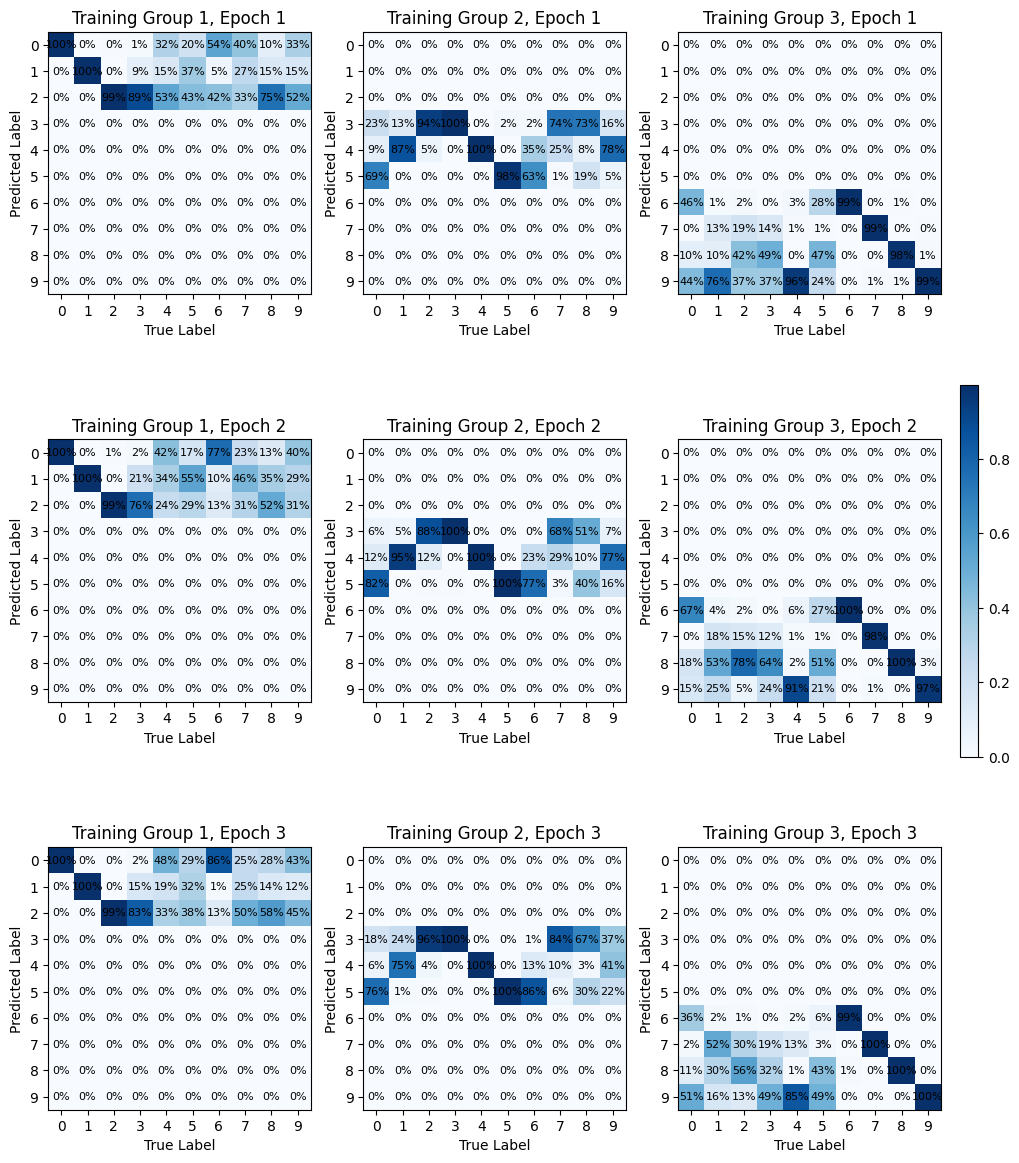

In [68]:
plot_cms(cm_group_set, normalize=True)

### Penultimate Layer PCA

In [70]:
μ_cgm, σ_cgm = monte_carlo_cgm(dim_subspace=1, dim_space=64, n_samples=100_000, seed=42)

In [71]:
print(μ_cgm, σ_cgm)

0.09930267499286188 0.07446991020776277


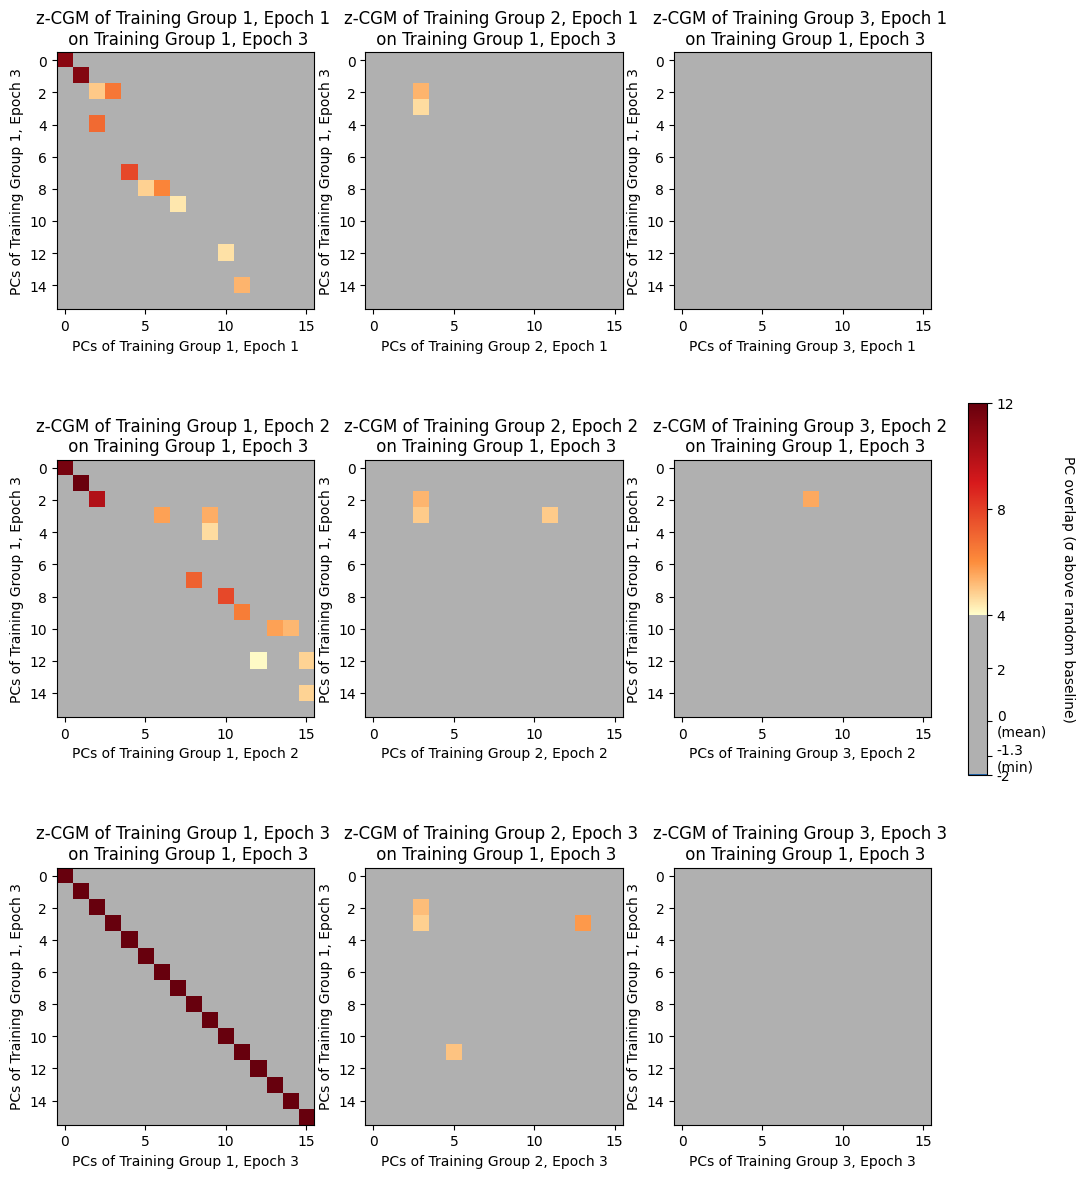

In [72]:
plot_cgms(pca_group_set, μ_cgm, σ_cgm, window=(0, num_old_pca_components), diagonalize=False)

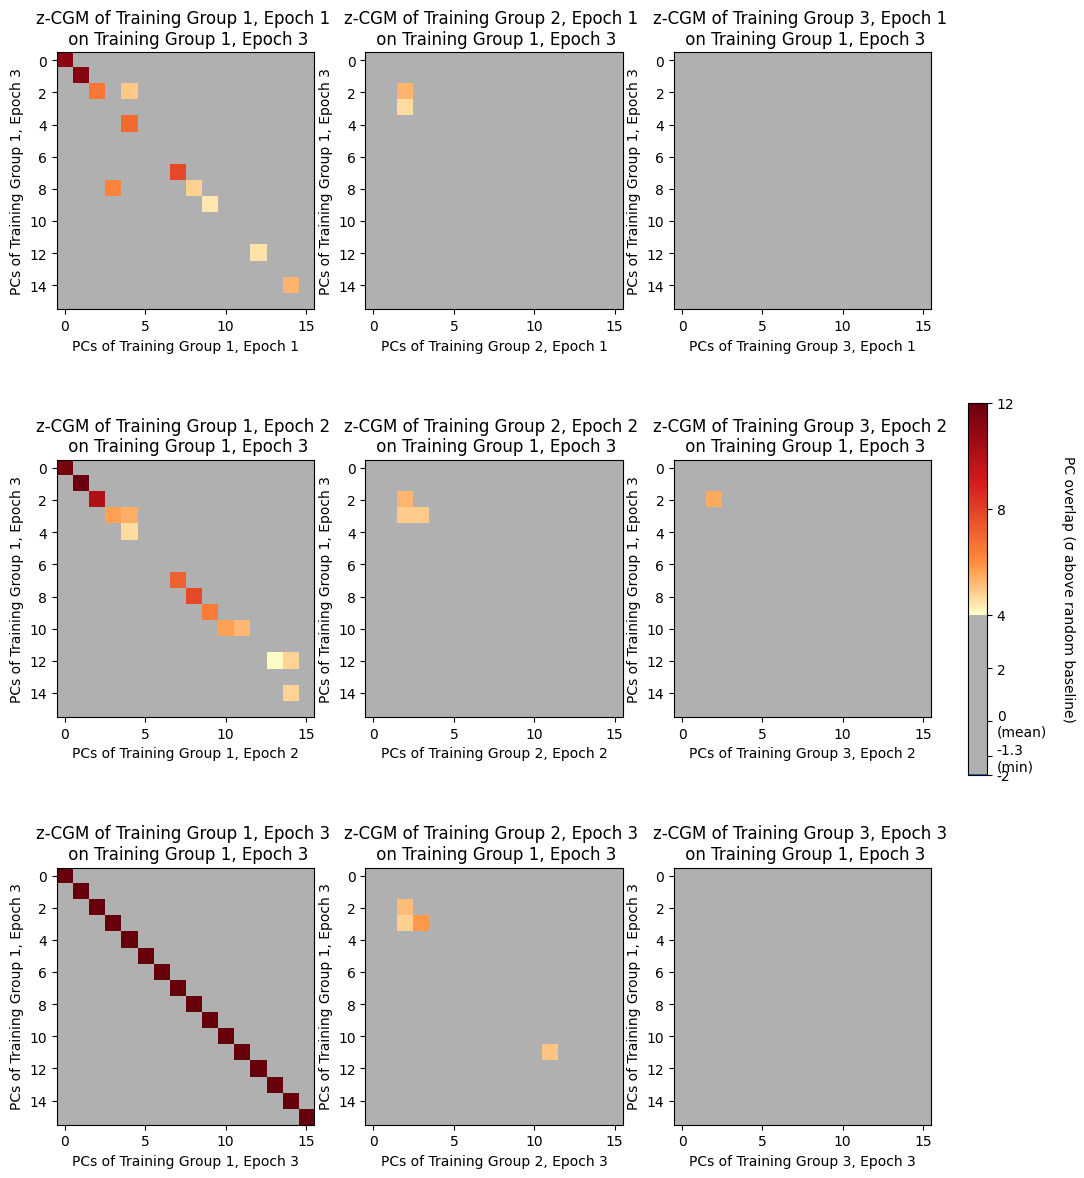

In [73]:
plot_cgms(pca_group_set, μ_cgm, σ_cgm, window=(0, num_old_pca_components), diagonalize=True)

### k-Means of Hidden Representations

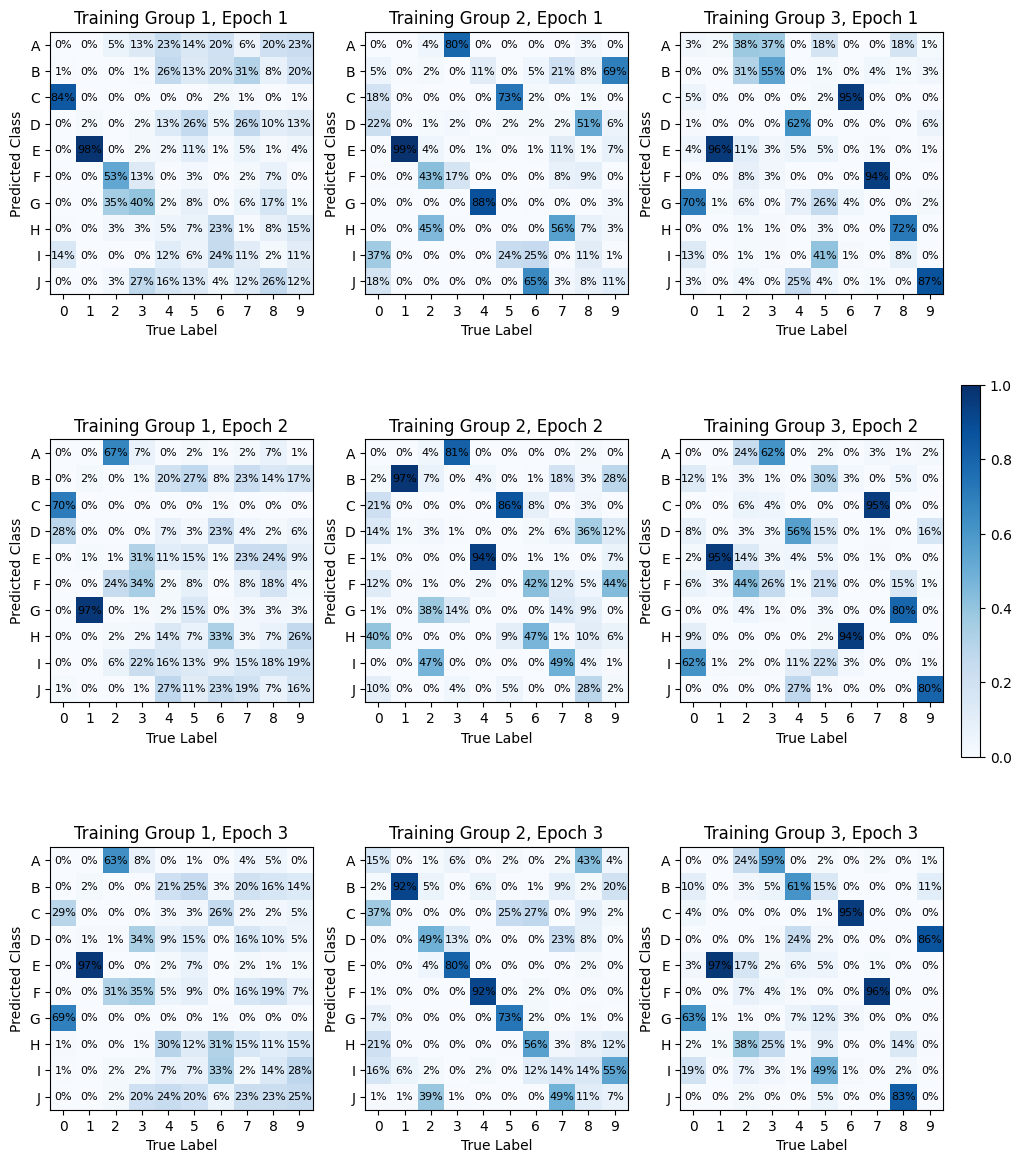

In [74]:
plot_kmeans(kmeans_group_set, diagonalize=False, normalize=True)

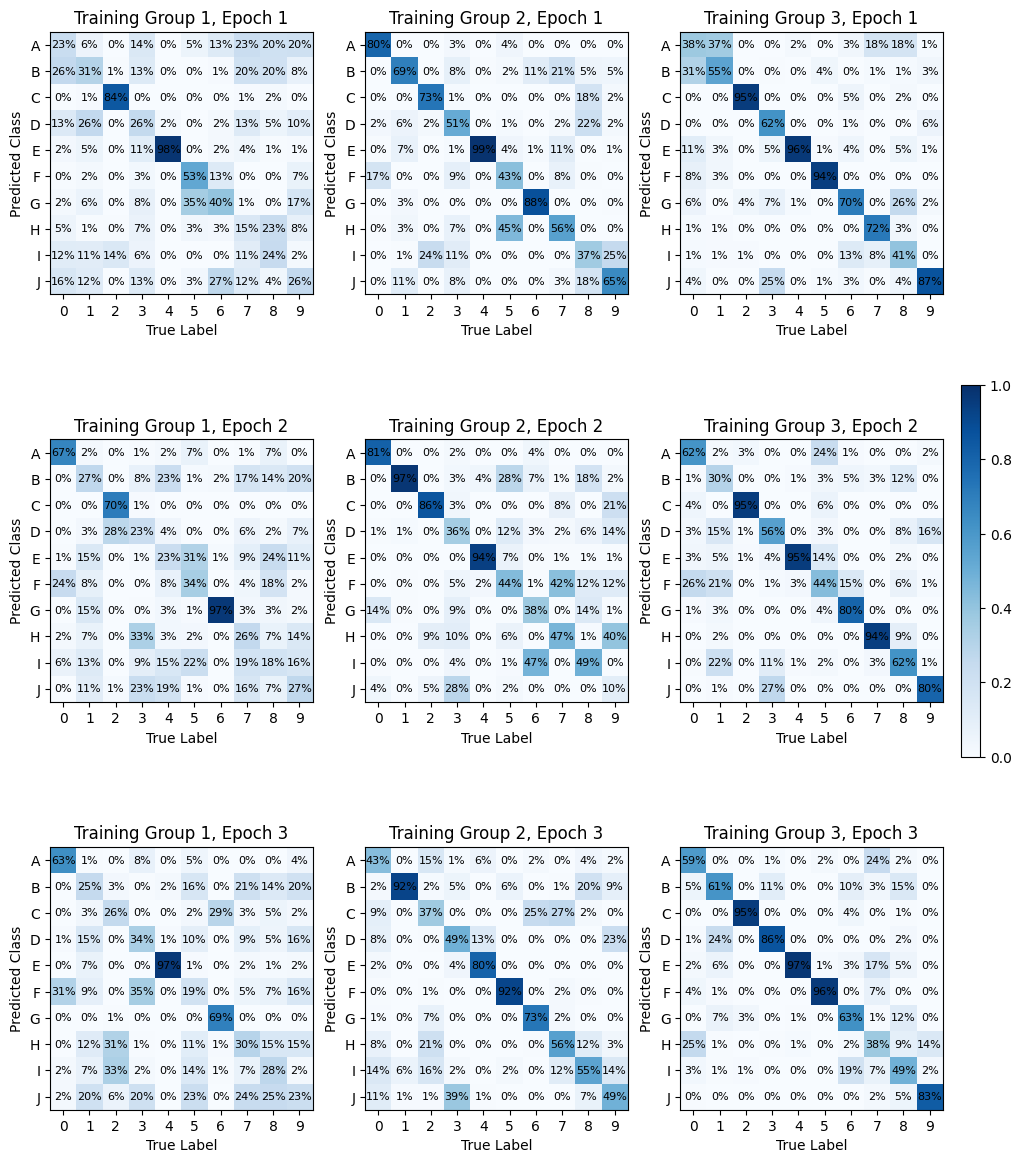

In [75]:
plot_kmeans(kmeans_group_set, diagonalize=True, normalize=True)

### Maximal Images

In [109]:
singleton_clusters = torch.eye(202)

In [111]:
maxims_group_set = {}

for i in tqdm(range(num_training_groups)):

    maxims_group_set[i] = get_maxims(model_group_set[i], singleton_clusters, num_steps=500, ε=0.01)

100%|██████████| 3/3 [02:24<00:00, 48.25s/it]


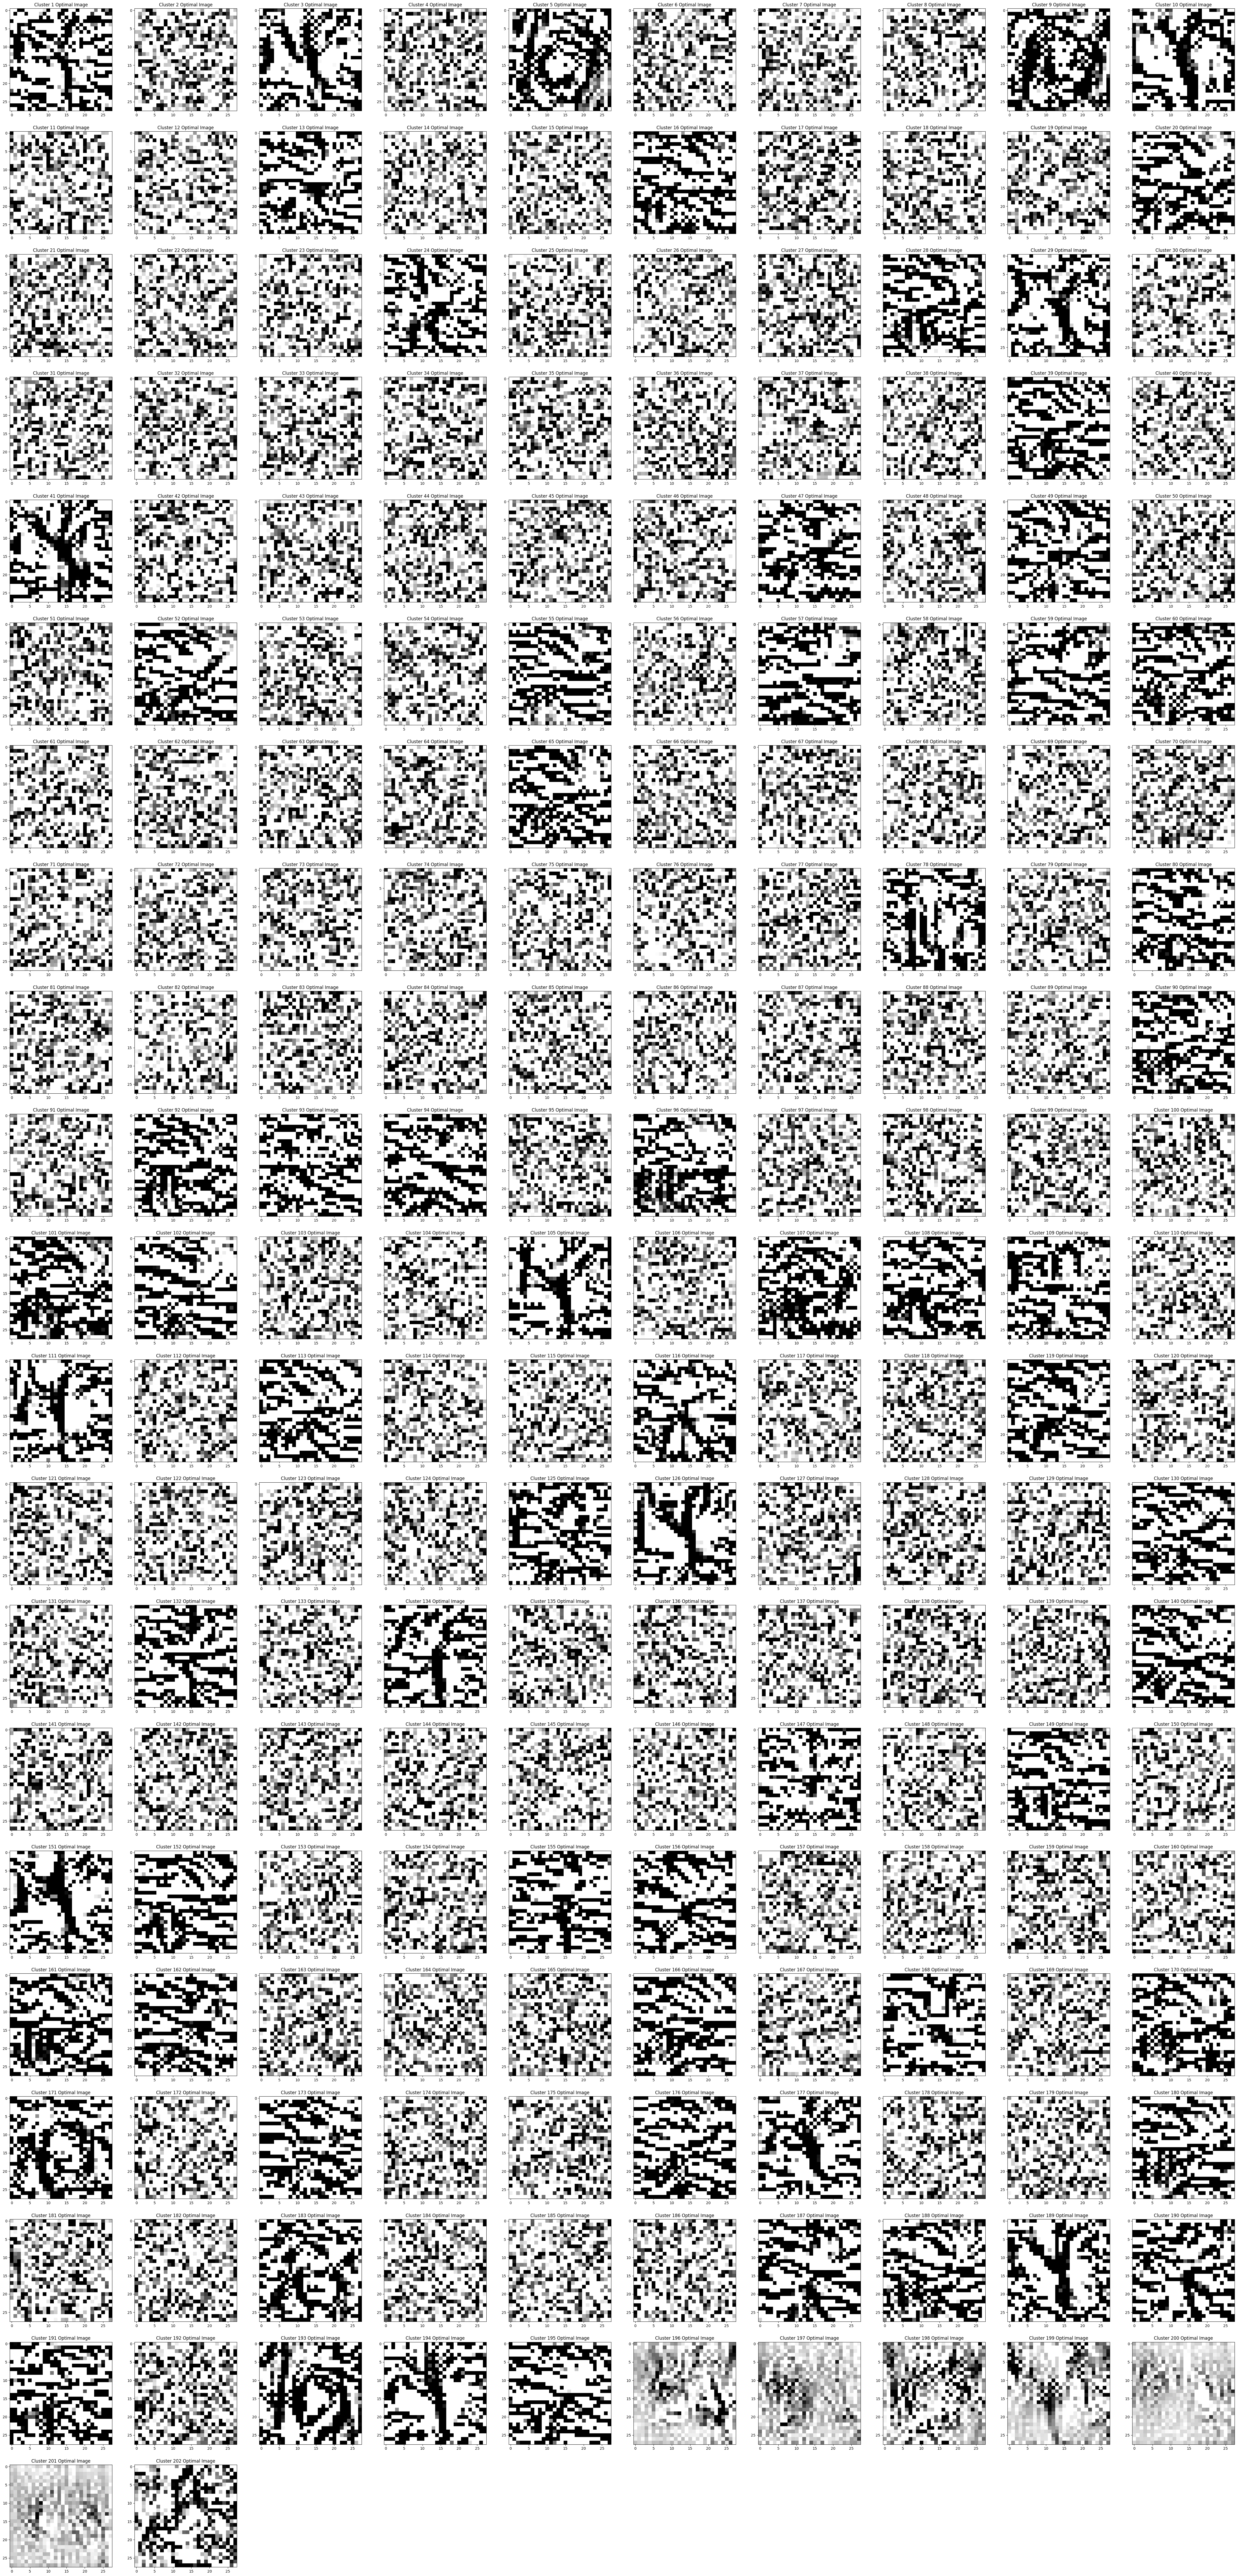

In [112]:
plot_maxims(maxims_group_set[0])

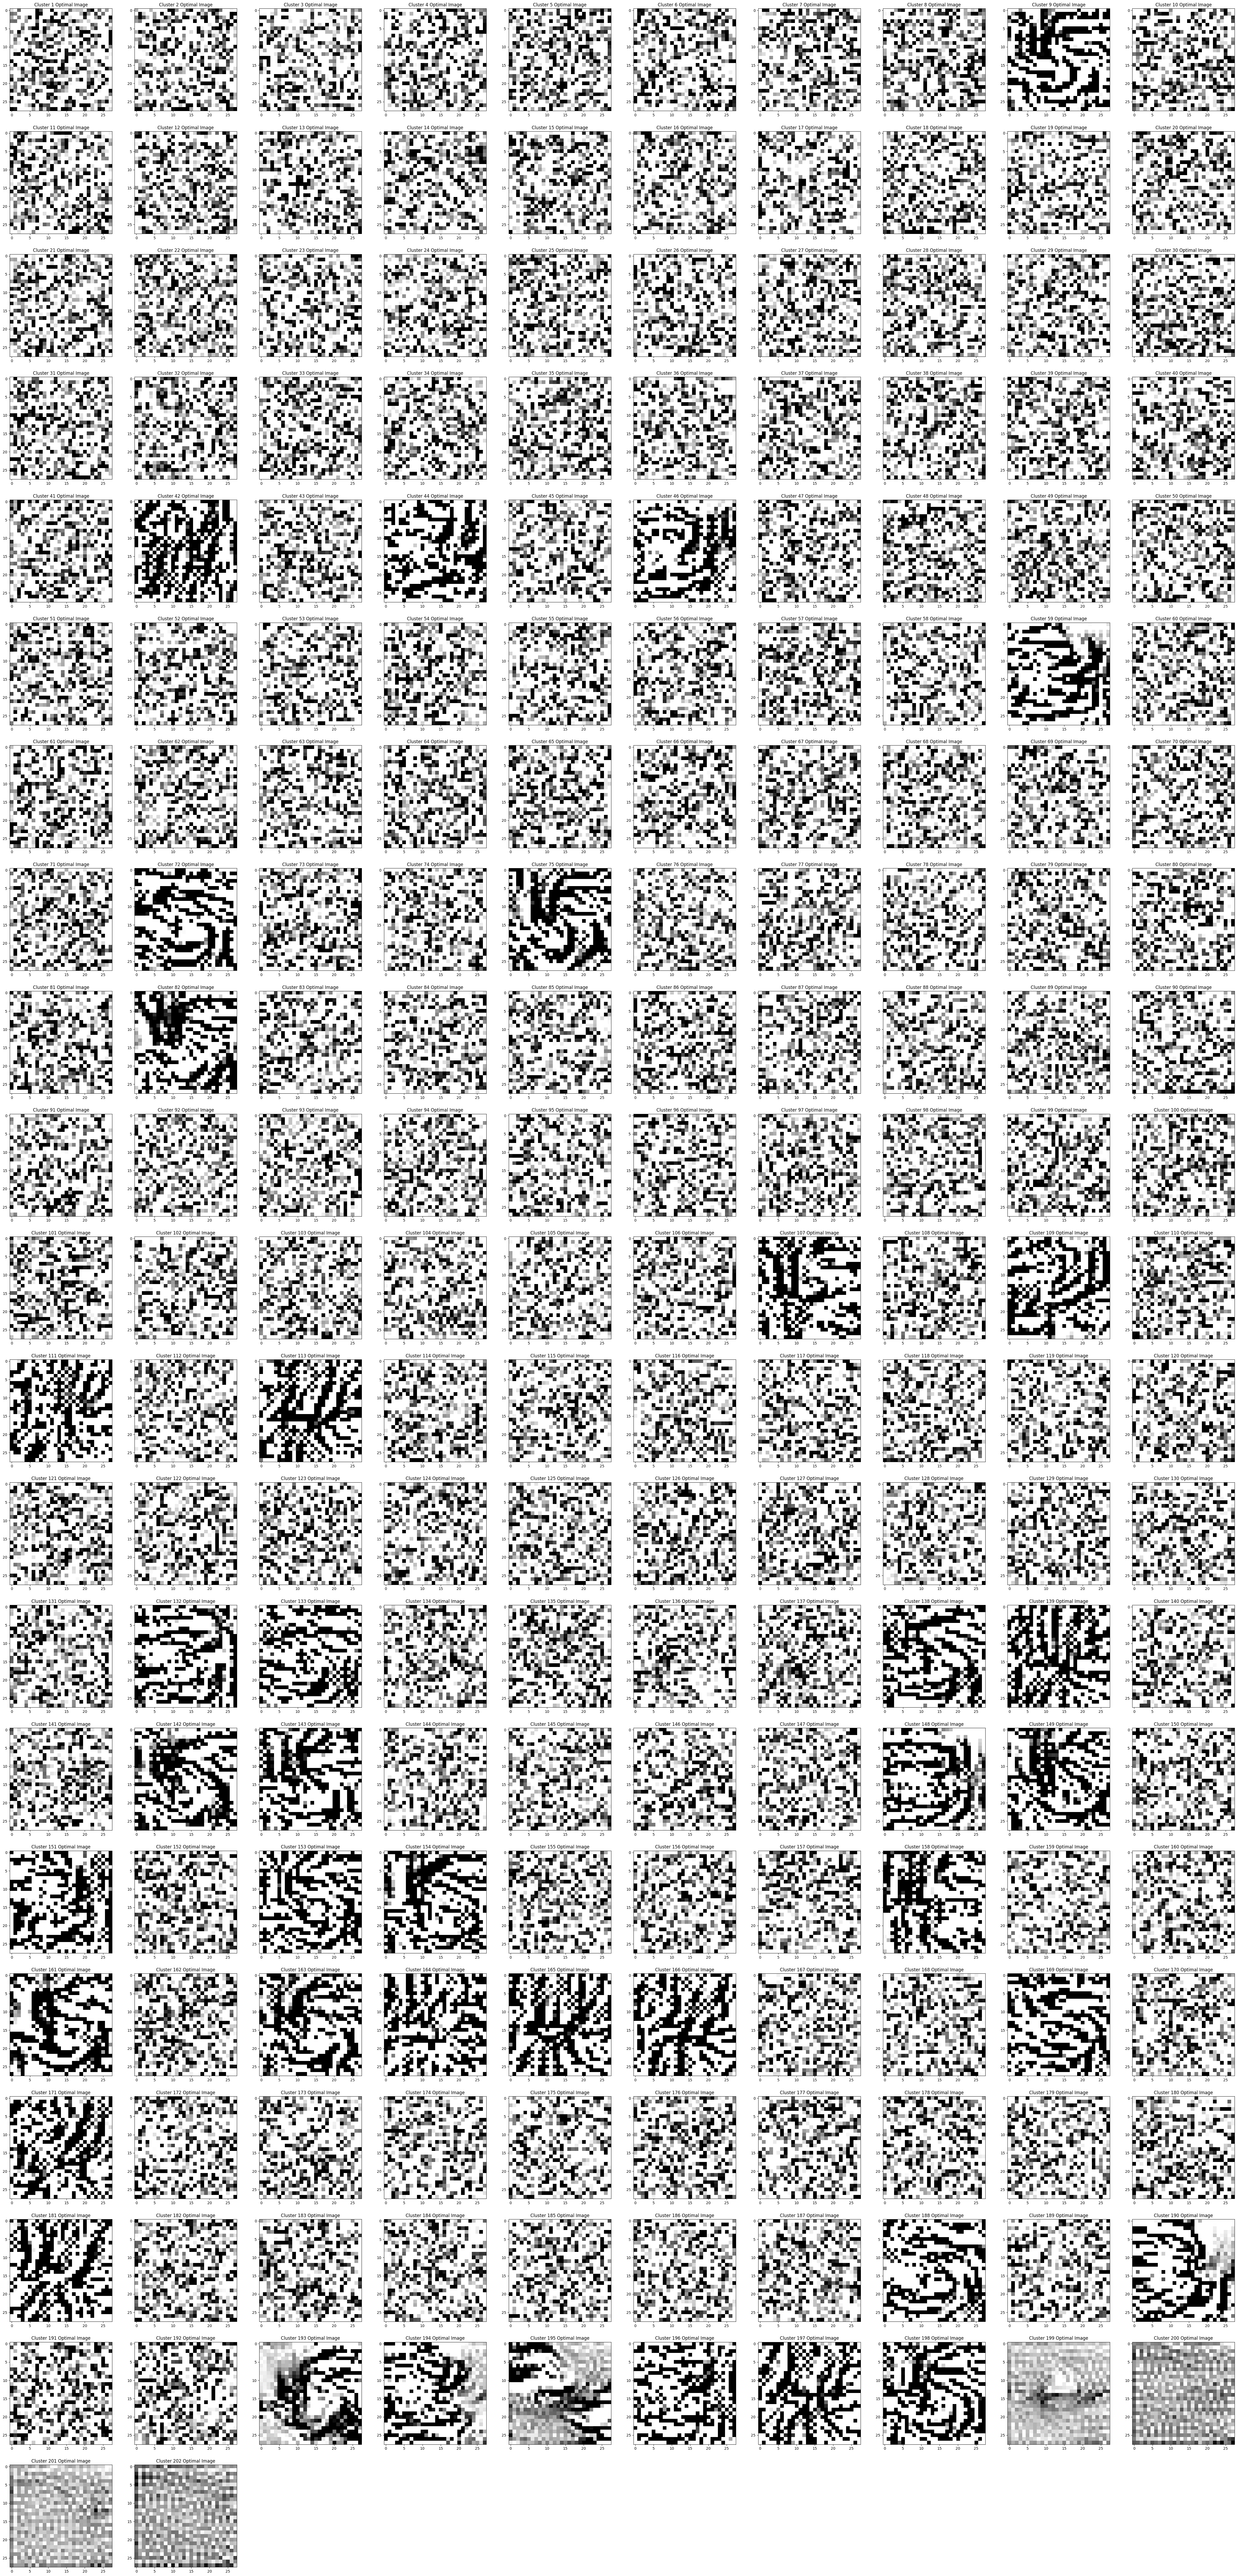

In [113]:
plot_maxims(maxims_group_set[1])

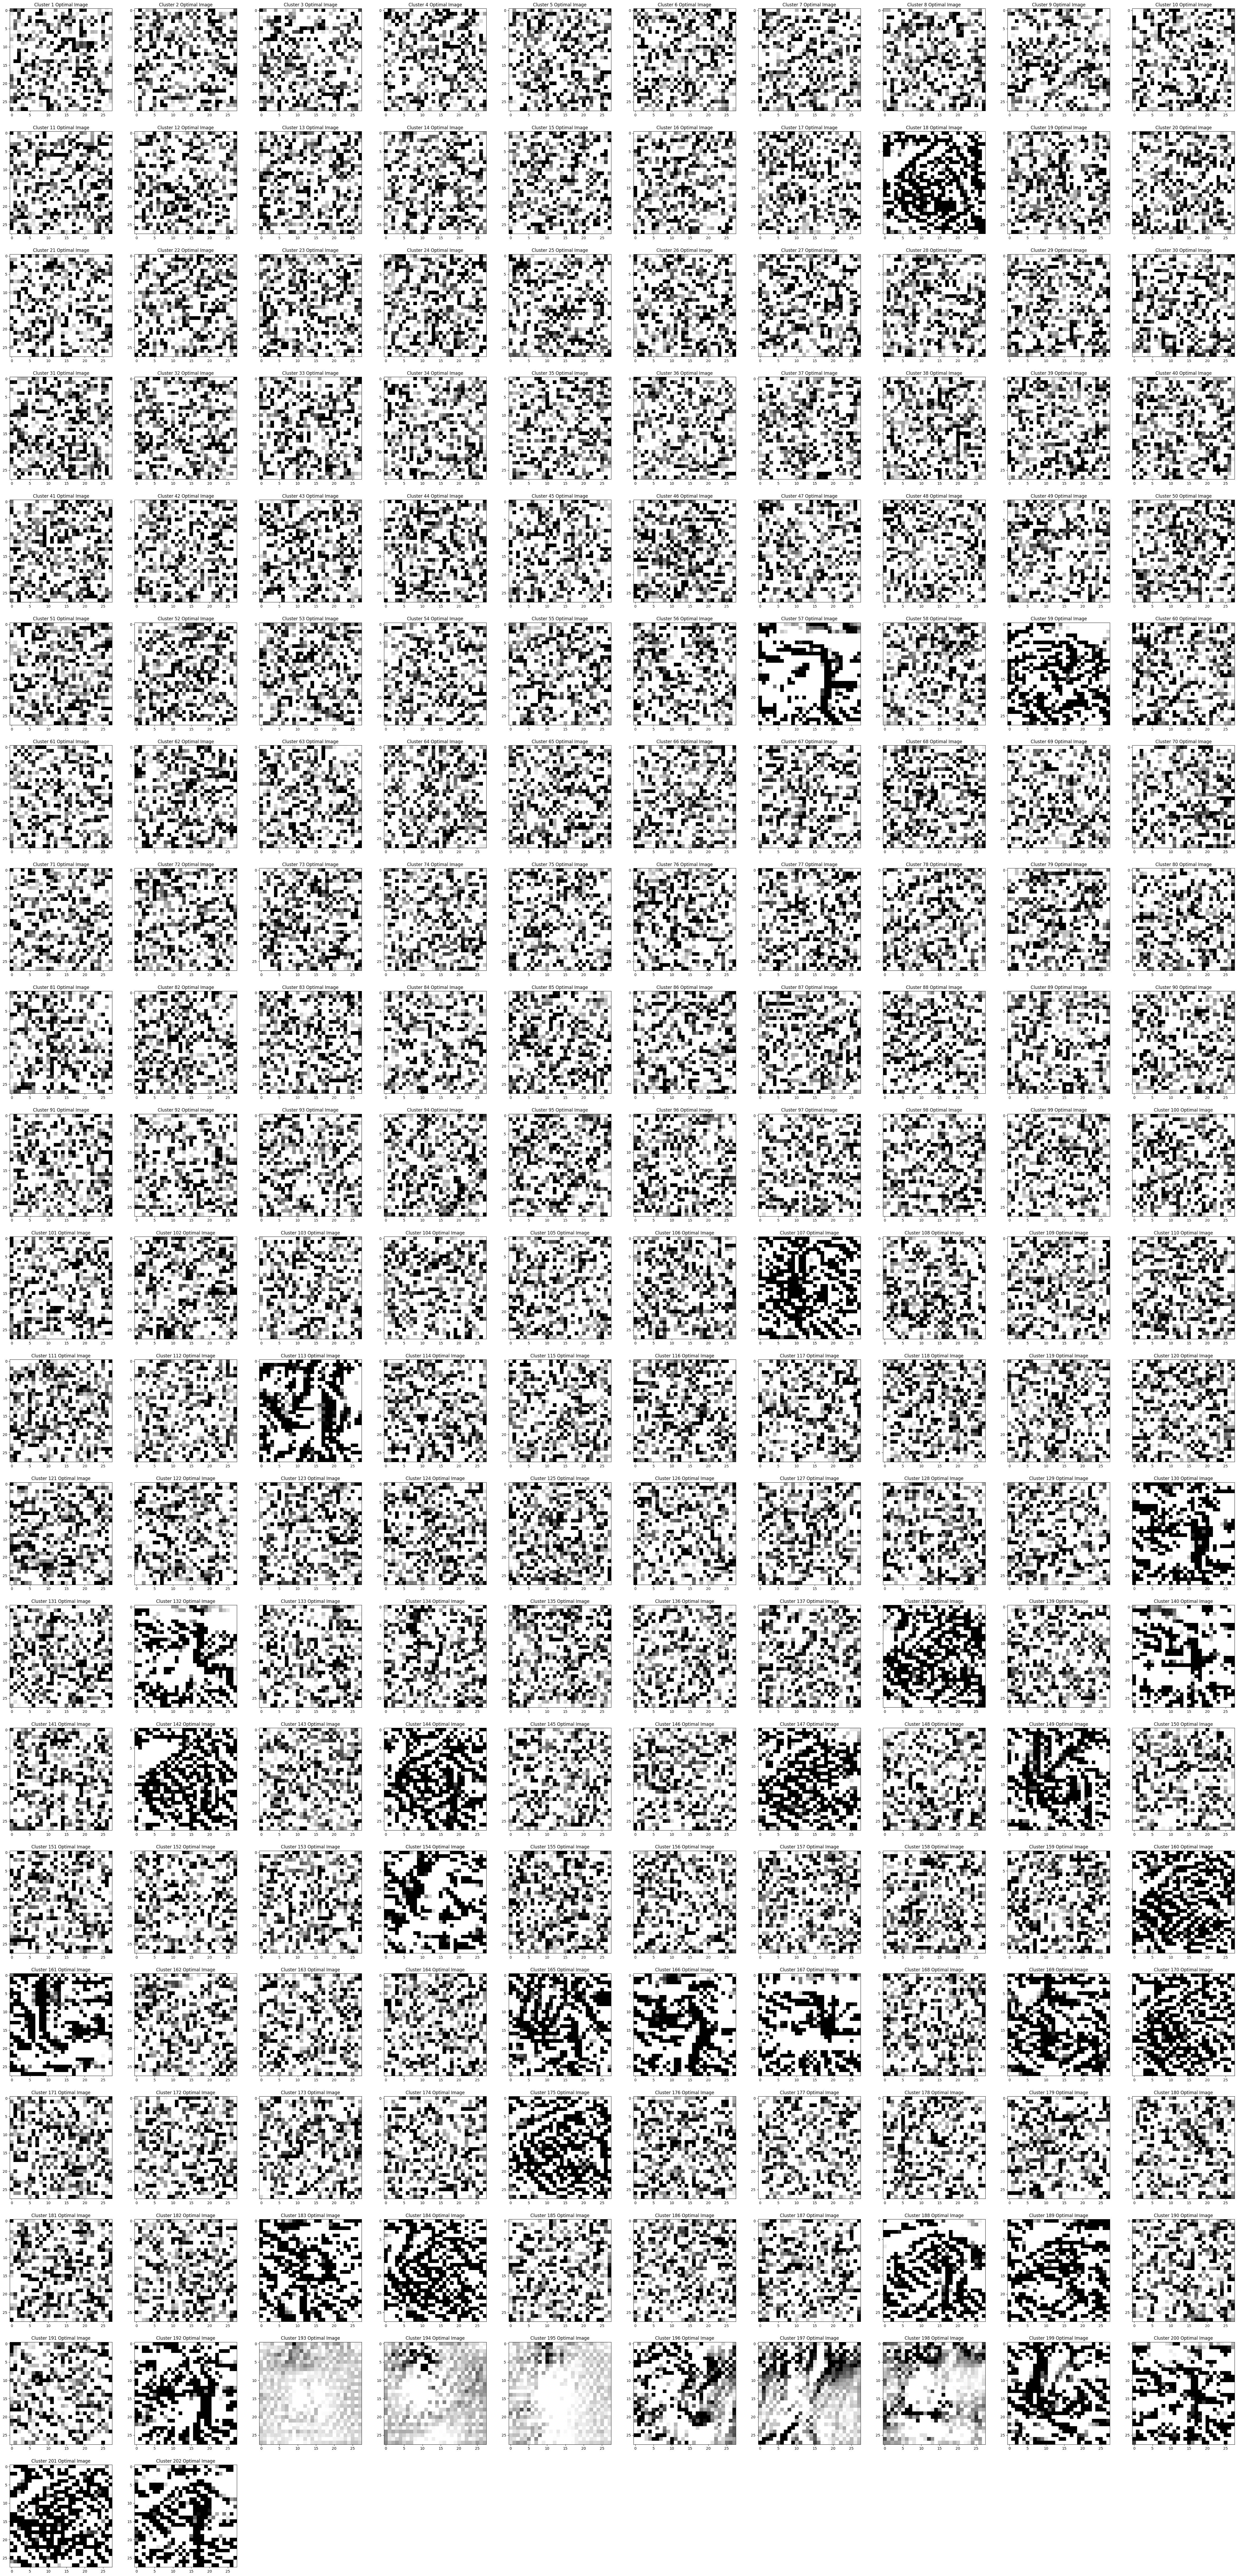

In [114]:
plot_maxims(maxims_group_set[2])

### Control Plot

In [115]:
rng = np.random.default_rng(seed=SEED)
 
U = rng.standard_normal((64, 64)) 
V = rng.standard_normal((64, 64))        

U, _ = np.linalg.qr(U)                                                   
V, _ = np.linalg.qr(V)                                                   

cgm = np.abs(np.einsum("di, dj -> ij", U, V))        

c_cgm = (cgm - μ_cgm)/σ_cgm

In [116]:
U.shape, V.shape

((64, 64), (64, 64))

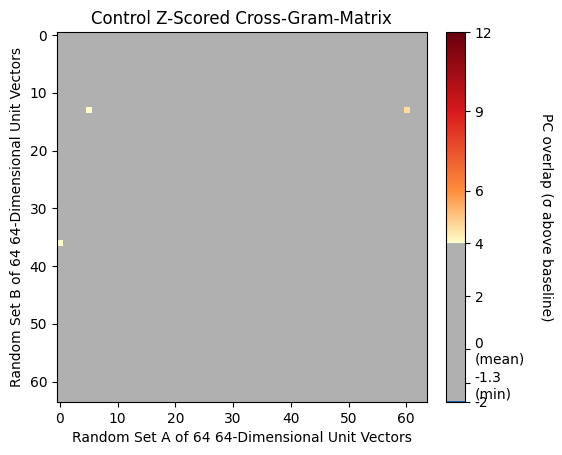

In [117]:
cgm_cmap, cgm_norm = make_colormap(
                                            vmin=-2,
                                            vmax=12,
                                            neutral_low=-2,     
                                            neutral_high=4,
                                            mid1 = 6,
                                            mid2 = 9
                                        )
 
CGM_TICKS  = [-2, -1.3,         0,              2,        4,        6,        9,       12]
CGM_LABELS = ['-2', '-1.3\n(min)', '0\n(mean)', '2', '4', '6', '9', '12']

fig = plt.figure()

im = plt.imshow(c_cgm, cmap=cgm_cmap, norm=cgm_norm)
cbar = plt.colorbar(im, ticks=CGM_TICKS, fraction=0.05, pad=0.04)
cbar.ax.set_yticklabels(CGM_LABELS)
cbar.set_label("PC overlap (σ above baseline)", rotation=270, labelpad=20)

plt.title(f"Control Z-Scored Cross-Gram-Matrix")
plt.xlabel(f"Random Set A of 64 64-Dimensional Unit Vectors")
plt.ylabel(f"Random Set B of 64 64-Dimensional Unit Vectors")

plt.show()